## **Challenge: Kepler’s Third Law and Exoplanet Analysis**

### **Your Tasks**

1. **Generate a synthetic dataset of exoplanets orbiting different stars**, including:
   - Semi-major axis \( a \) (in AU),
   - Orbital period \( P \) (in years), with some observational noise (this is optional),
   - Star mass \( M \) (in solar masses), which will be used to color the points.

2. **Fit a power-law relation** \( P = K a^b \) to the data and compare the exponent \( b \) with the expected value from Kepler’s Law.

3. **Create a log-log plot** of \( P \) vs. \( a \), with:
   - Error bars,
   - Points colored by stellar mass,
   - Overlayed fit line and random sample fits.


In [ ]:
# relevant imports

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## **Kepler’s Third Law**

Kepler’s Third Law states:

$$
P^2 = \frac{4\pi^2}{GM} a^3
$$

Where:
- \( P \) is the orbital period (in years),
- \( a \) is the semi-major axis (in AU),
- \( M \) is the mass of the central star (in solar masses),
- \( G \) is the gravitational constant (in $\text{AU}^3$ $\text{yr}^{-2}$ $\text{M}_{\text{sun}}^{-1}$)

### **Rearranging for \( P \)**

We rearrange for \( P \):

$$
P = \left( \frac{4\pi^2}{GM} \right)^{1/2} a^{3/2}
$$

This is a **power-law relation** of the form:

$$
P = K a^b
$$

Where:
- Theoretical expectation: \( b = $\frac{3}{2}$ = 1.5 \),
- \( K \) depends on the stellar mass \( M \):

$$
K = \left( \frac{4\pi^2}{GM} \right)^{1/2}
$$

Since our dataset includes planets around stars of different masses, our fitted \( K \) is an average over the range of stellar masses, and our fitted \( b \) should ideally be close to **1.5**.


In [25]:
# Constants
G = 39.478  # AU^3 yr^-2 M_sun^-1 (gravitational constant in convenient units)

In [26]:
# Randomly generate (np.random.uniform) synthetic data (semi-major axis and Mass) for 50 planets
num_planets = 50
a = np.random.uniform(0.1, 10, num_planets)  # Semi-major axes (AU)
M_star = np.random.uniform(0.5, 2.0, num_planets)  # Stellar masses (Solar masses)


In [27]:
# Calculate exact periods using Kepler's Third Law (using a function)
def kepler_third_law(a, M_star, G):
    P = np.sqrt((4 * np.pi**2 * a**3) / (G * M_star))
    return P

P_exact = kepler_third_law(a, M_star, G)

In [28]:
# Optional!!!!!
# Add observational noise (5% random variation)
P_obs = P_exact * np.random.normal(1, 0.05, num_planets)

In [29]:
# Define power-law function for fitting (hint, look at notes on Keplers Third Law at start of notebook)
def power_law(x, K, b):
    return K * x**b

In [ ]:
# Optional!!!!!
# Consider error estimates (15% errors in observed periods) and add an error to measurements (will be error bars later)
P_err = 0.15 * P_obs

In [31]:
# Fit log-log data
popt, pcov = curve_fit(power_law, a, P_obs, sigma=P_err, absolute_sigma=True)
K_fit, b_fit = popt
K_err, b_err = np.sqrt(np.diag(pcov))

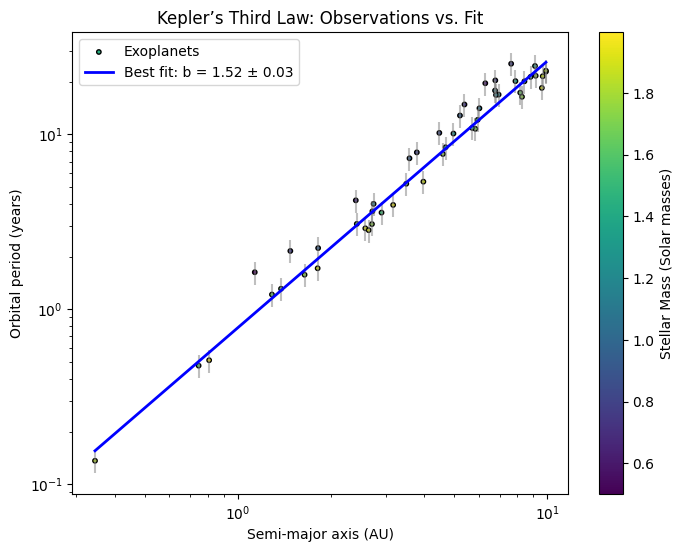

In [32]:
# Plot data (optional: with error bars) and line of fit on log-log axis
# Colour points by mass (choose a cmap that you like)
# Make sure to use labels and add a legend (for points and line of fit)

# Plot results
fig, ax = plt.subplots(figsize=(8, 6)) # subplots are good practice to use (even if just plotting one figure)
sc = ax.scatter(a, P_obs, c=M_star, cmap='viridis', edgecolor='k', label="Exoplanets", s = 10)
ax.errorbar(a, P_obs, yerr=P_err, fmt='none', ecolor='gray', alpha=0.5)

# Best fit curve
a_fit = np.logspace(np.log10(min(a)), np.log10(max(a)), 100)
P_fit = power_law(a_fit, *popt)
ax.plot(a_fit, P_fit, color='blue', linewidth=2, label=f"Best fit: b = {b_fit:.2f} ± {b_err:.2f}")

# Log-log scale
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Semi-major axis (AU)")
ax.set_ylabel("Orbital period (years)")
ax.set_title("Kepler’s Third Law: Observations vs. Fit")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Stellar Mass (Solar masses)")
ax.legend()
plt.show() # not really needed in Jupyter Notebooks

In [33]:
# Print your value for b (optional: with error from your fit line, hint: is in covariance matrix, pcov)
# Compare to the expected value of 1.5

# Print results
print(f"Fitted power-law exponent: b = {b_fit:.4f} ± {b_err:.4f}")
print("Expected value from Kepler’s Third Law: b = 1.5 and so looks to be within error")

Fitted power-law exponent: b = 1.5240 ± 0.0266
Expected value from Kepler’s Third Law: b = 1.5 and so looks to be within error
